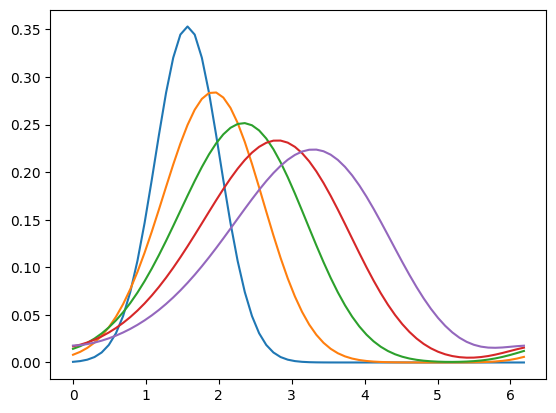

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

# parameters
n = 6 # number of qubits
N = 2**n # number of grid points
L = 2*np.pi # length of the box
dx = L/N # grid spacing
x = np.arange(N)*dx # grid points
times = np.arange(2, 10, 2)
D = 0.01 # diffusion coeff

c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x # velocity field
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L  # velocity field gradient

# initial condition
sigma = L/20
state_i = np.exp(-0.25*((x-dx*N/4)/sigma)**2)
state_i = state_i / np.linalg.norm(state_i) # normalize the initial state

j_indices = np.arange(N)
k_j = 2*np.pi /L * np.where(j_indices < N/2, j_indices, j_indices - N)
P1 = np.diag(1j*k_j)
P2 = np.diag(-k_j**2)
QFT, QFT_inv = get_qft_mat(n)
D1 = QFT_inv @ P1 @ QFT
D2 = QFT_inv @ P2 @ QFT

A = - (D*D2-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c)) - np.diag(cx))

plt.plot(x,state_i)
for t in times:

    U = expm(-A*t)
    final_state = U @ state_i
    final_state = final_state / np.linalg.norm(final_state) # normalize the final state
    plt.plot(x,final_state)

plt.show()